<h1>Project 1: Data Analysis Project<h1>

<h2> 1 Inequality in Denmark

### 1.1 The Gini coefficient and the top 10 percent share

In [1]:
# %pip install git+https://github.com/alemartinello/dstapi
# %pip install fredapi

In [2]:
import numpy as np
import matplotlib.pyplot as plt
from dstapi import DstApi
import pandas as pd

colors = plt.rcParams['axes.prop_cycle'].by_key()['color']
plt.rcParams.update({'axes.grid':True,'grid.color':'black','grid.alpha':'0.25','grid.linestyle':'--'})
plt.rcParams.update({'font.size': 14})


In [3]:
IFOR41 = DstApi('IFOR41')
IFOR41.tablesummary(language='en')


Table IFOR41: Income distribution on equivalised disposable income by indicator, municipality and time
Last update: 2025-12-01T08:00:00


,variable name,# values,First value,First value label,Last value,Last value label,Time variable
0,ULLIG,4,70,Gini coefficient,73,P90/10 (Upper decile boundary divided by lower),False
1,KOMMUNEDK,99,000,All Denmark,851,Aalborg,False
2,Tid,38,1987,1987,2024,2024,True


In [4]:
IFOR41.variable_levels('ULLIG',language='en') ##might not be necessary

,id,text
0,70,Gini coefficient
1,71,Hoover index
2,72,S80/S20 (Income quintile share ratio)
3,73,P90/10 (Upper decile boundary divided by lower)


In [5]:
params = {
    'table': 'IFOR41',
    'format': 'BULK', 
    'lang': 'en',
    'variables': [
        {'code': 'ULLIG', 'values': ['70']},
        {'code': 'KOMMUNEDK', 'values': ['000']},
        {'code': 'Tid', 'values': ['*']}, 
        ]
    }

ginidk = IFOR41.get_data(params=params)
ginidk.head(5)

,ULLIG,KOMMUNEDK,TID,INDHOLD
0,Gini coefficient,All Denmark,2016,28.97
1,Gini coefficient,All Denmark,1999,23.83
2,Gini coefficient,All Denmark,1988,22.06
3,Gini coefficient,All Denmark,2015,28.77
4,Gini coefficient,All Denmark,1989,21.93


In [6]:
ginidk=ginidk.drop(columns=['ULLIG','KOMMUNEDK'])
ginidk = ginidk.rename(columns={'INDHOLD':'gini', 'TID': 'year'})
ginidk= ginidk.set_index('year').sort_index()

ginidk.head(5)

,gini
year,
1987,22.07
1988,22.06
1989,21.93
1990,22.16
1991,21.99


Text(0, 0.5, 'Gini')

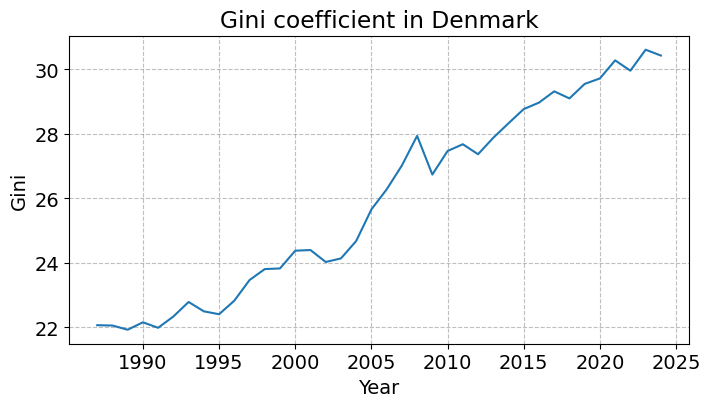

In [7]:
fig = plt.figure(figsize=(8,4))
ax = fig.add_subplot()
ax.plot(ginidk.index,ginidk['gini'].astype(float))
ax.set_title('Gini coefficient in Denmark')
ax.set_xlabel('Year')
ax.set_ylabel('Gini')

In [8]:
IFOR32 = DstApi('IFOR32')
IFOR32.tablesummary(language='en')

Table IFOR32: Avg. equivalised disposable Income in decile groups, by decile average, municipality and time
Last update: 2025-12-01T08:00:00


,variable name,# values,First value,First value label,Last value,Last value label,Time variable
0,DECILGEN,10,1DC,First decil,10DC,Tenth decil,False
1,KOMMUNEDK,99,000,All Denmark,851,Aalborg,False
2,Tid,38,1987,1987,2024,2024,True


In [9]:
params = {
    'table': 'IFOR32',
    'format': 'BULK', 
    'lang': 'en',
    'variables': [
        {'code': 'DECILGEN', 'values': ['*']},
        {'code': 'KOMMUNEDK', 'values': ['000']},
        {'code': 'Tid', 'values': ['*']}, 
        ]
    }

df = IFOR32.get_data(params=params)
df.head(10)
df.tail(10)

,DECILGEN,KOMMUNEDK,TID,INDHOLD
370,First decil,All Denmark,2001,62629
371,Second decil,All Denmark,2001,98552
372,Third decil,All Denmark,2001,114430
373,Fourth decil,All Denmark,2001,129885
374,Fifth decil,All Denmark,2001,144273
375,Sixth decil,All Denmark,2001,158392
376,Seventh decil,All Denmark,2001,173884
377,Eigth decil,All Denmark,2001,193021
378,Ninth decil,All Denmark,2001,221638
379,Tenth decil,All Denmark,2001,338942


In [10]:
df=df.drop(columns=['KOMMUNEDK'])
df = df.rename(columns={'INDHOLD':'income', 'TID': 'year'})
df= df.set_index('year').sort_index()

df.head(5)

,DECILGEN,income
year,,
1987,First decil,31418
1987,Ninth decil,123582
1987,Eigth decil,110184
1987,Seventh decil,100691
1987,Sixth decil,92777


<Axes: title={'center': 'Top 10% income share in Denmark'}, xlabel='Year', ylabel='Share of total income'>

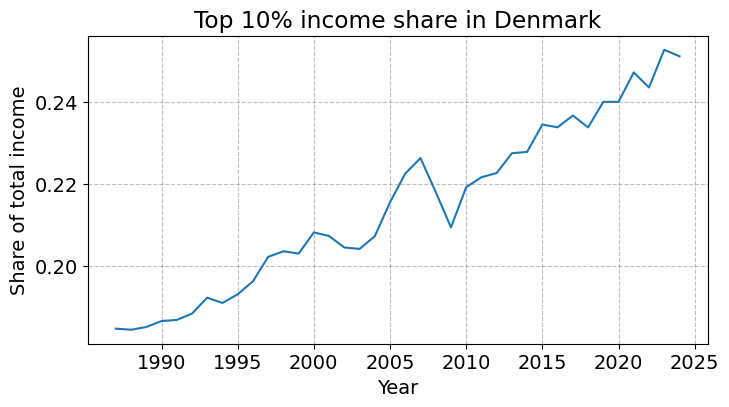

In [11]:
pivot = df.pivot_table(values='income', index=df.index, columns='DECILGEN', aggfunc='sum')
top10_share = pivot['Tenth decil'] / pivot.sum(axis=1)

top10_share.plot(title='Top 10% income share in Denmark', ylabel='Share of total income', xlabel='Year', figsize=(8,4))

#Describe how inequality in Denmark has developed since 1987. Do the two measures
tell the same story? 

Both graphs show gradually increasing inequality from 1987 to 2000, a slight dip from 2000 to ~2003 followed by a sharp spike that peaked immediately before the financial crisis and sharply fell during it, before continuing on its previous trend of gradually increasing from 2010-2024.


In [12]:
#Compute the correlation between them over time
np.corrcoef(ginidk['gini'].astype(float), top10_share)[0,1]





np.float64(0.9816415450527721)

### 1.2 Prediction

In [13]:
# Importing the packages

import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import minimize

In [14]:
# Setting up the prediction

y= ginidk['gini'].astype(float).values
t = ginidk.index.astype(int).values - 1987
t = t.astype(float)

S1 = lambda beta: sum((y-(beta[0] + beta[1]*t))**2)
S2 = lambda beta: sum((y-(beta[0] + beta[1]*t+beta[2]*t**2))**2)


In [15]:
# Solving the minimization problem

minproblin= minimize(S1, x0=(0,0), constraints=None)
minprobqua= minimize(S2, x0=(0,0,0), constraints=None)

beta0_lin, beta1_lin = minproblin.x
beta0_quad, beta1_quad, beta2_quad = minprobqua.x

print("beta linear=", beta0_lin, beta1_lin)
print("beta quadratic=", beta0_quad, beta1_quad, beta2_quad)

beta linear= 21.042753545648125 0.26354959467635763
beta quadratic= 21.304186697307134 0.21997579816762736 0.0011776761712922607


In [16]:
# Checking the answes against np.polyfit

coeff_lin = np.polyfit(t,y,1)
print(coeff_lin)

coeff_quad= np.polyfit(t,y,2)
print(coeff_quad)

[ 0.26354962 21.04275304]
[1.17769085e-03 2.19975061e-01 2.13042004e+01]


When looking at the minimization an the np.polyfit against eachother they both return the same coefficient. This indicate that we have done the minimization problem correct.

Text(0, 0.5, 'Gini')

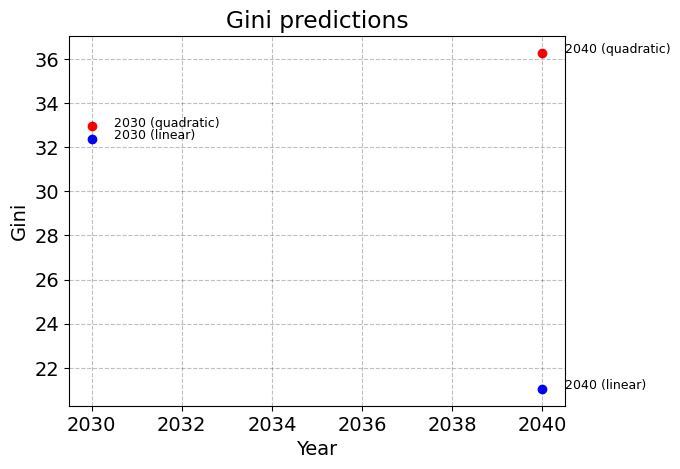

In [17]:
# Predicting and plotting the Gini coefficient in 2030 and 2040
t2030=2030-1987
t2040=2040-1987

"""
To find y, I set y to the formula S1 and S2 because the difference between them should be 0 if the formula is correctly minimized.
"""
lin_gin2030 = beta0_lin + beta1_lin*t2030
lin_gin2040 = beta0_lin + beta1_lin**t2040
quad_gin2030= beta0_quad + beta1_quad*t2030+beta2_quad*t2030**2
quad_gin2040= beta0_quad + beta1_quad*t2040+beta2_quad*t2040**2

plt.scatter(2030, lin_gin2030, color='blue')
plt.text(2030 + 0.5, lin_gin2030 + 0.001, '2030 (linear)', fontsize=9)

plt.scatter(2040, lin_gin2040, color='blue')
plt.text(2040 + 0.5, lin_gin2040 + 0.001, '2040 (linear)', fontsize=9)

plt.scatter(2030, quad_gin2030, color='red')
plt.text(2030 + 0.5, quad_gin2030 + 0.001, '2030 (quadratic)', fontsize=9)

plt.scatter(2040, quad_gin2040, color='red')
plt.text(2040 + 0.5, quad_gin2040 + 0.001, '2040 (quadratic)', fontsize=9)

plt.title('Gini predictions')
plt.xlabel('Year')
plt.ylabel('Gini')

Explaining the graph:
...

### 1.3 Municipalities

#### 1.3.1

Compute the correlation between the Gini coefficient and the top 10 percent
share across municipalities. Is it similar to the correlation over time you found
above?

...

In [18]:
IFOR41.tablesummary(language='en')

Table IFOR41: Income distribution on equivalised disposable income by indicator, municipality and time
Last update: 2025-12-01T08:00:00


,variable name,# values,First value,First value label,Last value,Last value label,Time variable
0,ULLIG,4,70,Gini coefficient,73,P90/10 (Upper decile boundary divided by lower),False
1,KOMMUNEDK,99,000,All Denmark,851,Aalborg,False
2,Tid,38,1987,1987,2024,2024,True


In [19]:
"""
Gini across municipalities
"""
params_muni_gini = {
    'table': 'IFOR41',
    'format': 'BULK', 
    'lang': 'en',
    'variables': [
        {'code': 'ULLIG', 'values': ['70']},
        {'code': 'KOMMUNEDK', 'values': ['*']},
        {'code': 'Tid', 'values': ['*']}, 
        ]
    }

municip_gini = IFOR41.get_data(params=params_muni_gini)
municip_gini.head(5)

,ULLIG,KOMMUNEDK,TID,INDHOLD
0,Gini coefficient,All Denmark,2016,28.97
1,Gini coefficient,Copenhagen,2016,33.24
2,Gini coefficient,Frederiksberg,2016,34.85
3,Gini coefficient,Ballerup,2016,25.77
4,Gini coefficient,Brøndby,2016,25.71


In [20]:

municip_gini=municip_gini.drop(columns=['ULLIG',])
municip_gini = municip_gini.rename(columns={'INDHOLD':'gini', 'TID': 'year','KOMMUNEDK':'municipalities'})
municip_gini= municip_gini.set_index('year').sort_index()

display(municip_gini)

,municipalities,gini
year,,
1987,Hjørring,21.96
1987,Greve,18.64
1987,Køge,19.52
1987,Halsnæs,18.50
1987,Roskilde,20.54
...,...,...
2024,Greve,26.35
2024,Frederikssund,26.11
2024,Egedal,23.85


In [21]:
IFOR32.tablesummary(language='en')

Table IFOR32: Avg. equivalised disposable Income in decile groups, by decile average, municipality and time
Last update: 2025-12-01T08:00:00


,variable name,# values,First value,First value label,Last value,Last value label,Time variable
0,DECILGEN,10,1DC,First decil,10DC,Tenth decil,False
1,KOMMUNEDK,99,000,All Denmark,851,Aalborg,False
2,Tid,38,1987,1987,2024,2024,True


In [22]:
"""
Top 10 share across municipalities.
"""

params_muni_top10 = {
    'table': 'IFOR32',
    'format': 'BULK', 
    'lang': 'en',
    'variables': [
        {'code': 'DECILGEN', 'values': ['*']},
        {'code': 'KOMMUNEDK', 'values': ['*']},
        {'code': 'Tid', 'values': ['*']}, 
        ]
    }

municip_top10 = IFOR32.get_data(params=params_muni_top10)
display(municip_top10)

,DECILGEN,KOMMUNEDK,TID,INDHOLD
0,Second decil,Odense,2013,123841
1,Third decil,Odense,2013,150153
2,Fourth decil,Odense,2013,170790
3,Fifth decil,Odense,2013,193979
4,Sixth decil,Odense,2013,218942
...,...,...,...,...
37615,Seventh decil,Nyborg,2017,260847
37616,Eigth decil,Nyborg,2017,290986
37617,Ninth decil,Nyborg,2017,335590
37618,Tenth decil,Nyborg,2017,500383


In [23]:

municip_top10 = municip_top10.rename(columns={'INDHOLD':'income', 'TID': 'year','KOMMUNEDK':'municipalities'})
municip_top10= municip_top10.set_index('year').sort_index()

municip_top10.head(5)

,DECILGEN,municipalities,income
year,,,
1987,Sixth decil,Bornholm,85526
1987,First decil,Frederikshavn,32887
1987,Second decil,Frederikshavn,59922
1987,Third decil,Frederikshavn,68777
1987,Fourth decil,Frederikshavn,76841


In [24]:
municip_top10_reset = municip_top10.reset_index()

pivot_muni = municip_top10_reset.pivot_table(
    values='income',
    index=['year', 'municipalities'],
    columns='DECILGEN',
    aggfunc='sum'
)

municip_top10_share = pivot_muni['Tenth decil'] / pivot.sum(axis=1)

display(municip_top10_share)

year  municipalities 
1987  Aabenraa           0.174965
      Aalborg            0.170437
      Aarhus             0.180832
      Albertslund        0.176451
      All Denmark        0.184549
                           ...   
2024  Vejle              0.236771
      Vesthimmerlands    0.200238
      Viborg             0.208468
      Vordingborg        0.189599
      Ærø                0.176300
Length: 3762, dtype: float64

In [25]:
combined = pd.merge(
    municip_gini.reset_index(),
    municip_top10_share.reset_index(name='top10_share'),
    on=['year', 'municipalities'],
    how='inner'
)

combined = combined.sort_values(['municipalities', 'year']).reset_index(drop=True)

display(combined)

,year,municipalities,gini,top10_share
0,1987,Aabenraa,21.33,0.174965
1,1988,Aabenraa,21.51,0.174845
2,1989,Aabenraa,20.74,0.174342
3,1990,Aabenraa,20.83,0.175503
4,1991,Aabenraa,20.86,0.180219
...,...,...,...,...
3757,2020,Ærø,25.61,0.175799
3758,2021,Ærø,26.63,0.180296
3759,2022,Ærø,27.02,0.178989
3760,2023,Ærø,27.67,0.177187


In [26]:
combined['gini'] = combined['gini'].astype(float)
combined['top10_share'] = combined['top10_share'].astype(float)

In [27]:
combined[['diff_gini','diff_top10_share']] = combined.groupby('municipalities')[['gini','top10_share']].diff()
combined.head(20)

,year,municipalities,gini,top10_share,diff_gini,diff_top10_share
0,1987,Aabenraa,21.33,0.174965,NaN,NaN
1,1988,Aabenraa,21.51,0.174845,0.18,-0.000121
2,1989,Aabenraa,20.74,0.174342,-0.77,-0.000503
3,1990,Aabenraa,20.83,0.175503,0.09,0.001161
4,1991,Aabenraa,20.86,0.180219,0.03,0.004716
5,1992,Aabenraa,20.96,0.180881,0.10,0.000662
6,1993,Aabenraa,21.57,0.187006,0.61,0.006124
7,1994,Aabenraa,21.22,0.188432,-0.35,0.001426
8,1995,Aabenraa,21.26,0.191632,0.04,0.003200
9,1996,Aabenraa,21.43,0.193367,0.17,0.001735


In [28]:
corr=combined.groupby('municipalities')['diff_gini'].corr(combined['diff_top10_share']).rename('correlation')
mean_correlation=corr.mean()
print(f'{mean_correlation = :.3f}')

mean_correlation = 0.644


In [29]:
corr = corr.sort_values()
print(corr)

municipalities
Sønderborg     -0.059326
Brønderslev     0.213366
Assens          0.230789
Kalundborg      0.268913
Guldborgsund    0.292057
                  ...   
Egedal          0.934802
Solrød          0.942683
Vejen           0.967018
Fredensborg     0.974044
Billund         0.995300
Name: correlation, Length: 99, dtype: float64


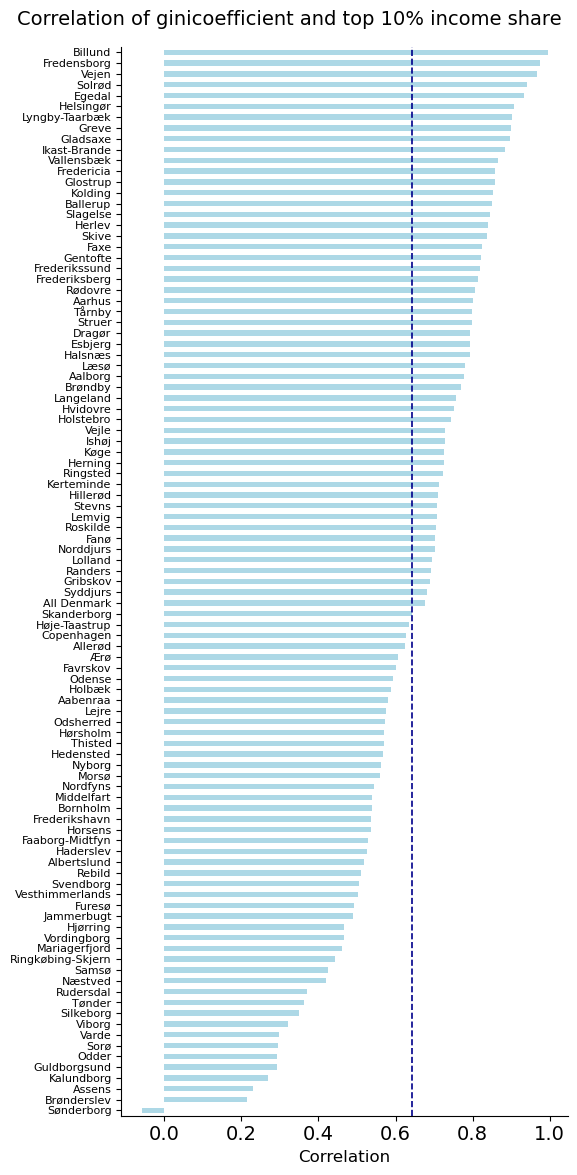

In [30]:
fig, ax = plt.subplots(figsize=(6, 12))

ax.barh(corr.index, corr.values,height=0.5, color='lightblue')


ax.axvline(mean_correlation,color='darkblue',linestyle='--',linewidth=1.2,label=f'Mean = {mean_correlation:.2f}')

ax.set_xlabel('Correlation',fontsize=12)

ax.set_yticks(range(len(corr.index)))
ax.set_yticks(np.arange(len(corr.index))*1)
ax.set_yticklabels(corr.index,fontsize=8)
ax.set_ylim(-0.5,len(corr.index)-0.5)


ax.grid(False)
for spine in ['top', 'right']:
    ax.spines[spine].set_visible(False)


fig.suptitle('Correlation of ginicoefficient and top 10% income share',fontsize=14)
fig.tight_layout()

#### 1.3.2

In [31]:
#Sorting gini for 2024
gini_2024 = municip_gini.loc[2024].sort_values('gini')

#Finding the smallest and largest gini coefficients
smallest_gini = gini_2024[['KOMMUNEDK', 'gini']].head(10)
largest_gini = gini_2024[['KOMMUNEDK', 'gini']].tail(10)

print("10 most equal municipalities: ", smallest_gini)
print("10 most unequal municipalities: ", largest_gini)

KeyError: "['KOMMUNEDK'] not in index"

#### 1.3.3

In [ ]:
gini_2024 = municip_gini[municip_gini['year'] == 2024][['KOMMUNEDK', 'gini']].rename(columns={'gini': 'gini_2024'})
gini_1987 = municip_gini[municip_gini['year'] == 1987][['KOMMUNEDK', 'gini']].rename(columns={'gini': 'gini_1987'})

gini_change = gini_2024.merge(gini_1987, on='KOMMUNEDK', how='inner')


gini_change['gini_change'] = gini_change['gini_2024'].astype(float) - gini_change['gini_1987'].astype(float)

gini_change_sorted = gini_change.sort_values('gini_change', ascending=False)


# Biggest change
print("Biggest change in Gini: ", gini_change_sorted.head(10))

# Smallest change
print("Smallest change in Gini", gini_change.sort_values('gini_change', ascending=True).head(10))

Biggest change in Gini:           KOMMUNEDK gini_2024 gini_1987  gini_change
23           Vejen     46.32     21.20        25.12
63       Rudersdal     47.31     29.05        18.26
49        Gentofte     49.04     31.10        17.94
51  Lyngby-Taarbæk     39.28     24.97        14.31
29      Copenhagen     34.97     23.05        11.92
31        Hørsholm     40.07     28.39        11.68
58     Fredensborg     32.76     21.17        11.59
96          Aarhus     33.43     22.10        11.33
62   Frederiksberg     36.54     25.28        11.26
55      Vallensbæk     26.70     15.90        10.80
Smallest change in Gini           KOMMUNEDK gini_2024 gini_1987  gini_change
5              Fanø     26.34     25.67         0.67
27              Ærø     26.98     24.63         2.35
40             Faxe     24.09     21.64         2.45
67             Læsø     25.41     22.81         2.60
81         Bornholm     24.03     21.31         2.72
84  Faaborg-Midtfyn     23.77     20.88         2.89
75      

### 1.4 Extension

In [ ]:
AULP01 = DstApi('AULP01') 

AULP01.tablesummary(language='en')

Table AULP01: Full-time unemployed persons in per cent of the labour force by region, age, sex and time
Last update: 2026-04-14T08:00:00


,variable name,# values,First value,First value label,Last value,Last value label,Time variable
0,OMRÅDE,117,000,All Denmark,997,Abroad,False
1,ALDER,10,TOT,"Age, total",6099,60 year and over,False
2,KØN,3,TOT,Total,K,Women,False
3,Tid,19,2007,2007,2025,2025,True


In [ ]:
params = {
    'table': 'AULP01',
    'format': 'BULK', 
    'lang': 'en',
    'variables': [
        {'code': 'OMRÅDE', 'values': ['*']},
        {'code': 'ALDER', 'values': ['TOT']},
        {'code': 'KØN', 'values': ['TOT']}, 
        {'code': 'Tid', 'values': ['*']}, 
        ]
    }

unemployment = AULP01.get_data(params=params)
unemployment.head(5)

,OMRÅDE,ALDER,KØN,TID,INDHOLD
0,All Denmark,"Age, total",Total,2013,5.8
1,Province Byen København,"Age, total",Total,2013,6.9
2,Province Københavns omegn,"Age, total",Total,2013,5.9
3,Province Nordsjælland,"Age, total",Total,2013,4.4
4,Province Bornholm,"Age, total",Total,2013,7.0


In [ ]:
unemployment=unemployment.drop(columns=['ALDER','KØN'])
unemployment = unemployment.rename(columns={'INDHOLD':'unemployment', 'OMRÅDE': 'municipality', 'TID': 'year'})
unemployment= unemployment.set_index('year').sort_index()

display(unemployment)

,municipality,unemployment
year,,
2007,Faaborg-Midtfyn,3.6
2007,Slagelse,4.6
2007,Stevns,3.3
2007,Sorø,3.0
2007,Lejre,1.9
...,...,...
2025,Hvidovre,2.8
2025,Høje-Taastrup,3.8
2025,Lyngby-Taarbæk,2.4


In [ ]:
drop_rows = unemployment.municipality.str.contains('Region')
drop_rows  |= unemployment.municipality.str.contains('Province')
drop_rows |= unemployment.municipality.str.contains('All Denmark')
unemployment.loc[~drop_rows,:].iloc[:5,:5]

,municipality,unemployment
year,,
2007,Faaborg-Midtfyn,3.6
2007,Slagelse,4.6
2007,Stevns,3.3
2007,Sorø,3.0
2007,Lejre,1.9


In [ ]:
unemployment= unemployment.loc[drop_rows==False] # keep everything else
unemployment.iloc[:5,:5]

,municipality,unemployment
year,,
2007,Faaborg-Midtfyn,3.6
2007,Slagelse,4.6
2007,Stevns,3.3
2007,Sorø,3.0
2007,Lejre,1.9


In [ ]:
unemployment = unemployment.reset_index().sort_values(['year','municipality']).reset_index(drop=True) # drop=True to avoid adding old index as a column
unemployment.iloc[:5,:5]

,year,municipality,unemployment
0,2007,Aabenraa,3.8
1,2007,Aalborg,5.1
2,2007,Aarhus,3.9
3,2007,Albertslund,4.8
4,2007,Allerød,1.6


<h2> 2 Simulating the income distribution

### 2.1 The model

In [ ]:
import pickle
import numpy as np

from scipy.stats import norm 

In [ ]:
from income_simulation import simulate_income_distribution, gini


N=50000
p_e=(0.4,0.35,0.25)
s_e=(1,3,5)
h_e0=(1.00,1.20,1.55)
delta_e=(0.010,0.020,0.030)
delta=(0.06)
sigma_psi=0.1
lambda_psi=0.6
sigma=0.05
y_su=0.45
rho=0.60
y_floor=0.35
age_min=18
age_max=65
seed=123

result = simulate_income_distribution(N, p_e, s_e, h_e0, delta_e, delta, sigma_psi,
                                      lam, sigma, y_su, rho, y_floor,
                                       age_min, age_max, seed)

ages = result['ages']
income = result['income']      
employed = result['employed']
e = result['education']

### 2.2 Simulate the income distribution

### 2.3 Compute the Gini coefficient

### 2.4 What drives inequality?

### 2.5 Extension: more risk